# Bias-Variance Tradeoff, Regularization, Ridge and Lasso Regression
## DA5401W - Data Analytics Lab
**Instructor:** Dr. Arun B Ayyar

---

This comprehensive notebook covers:
1. **Bias-Variance Tradeoff:** Understanding model complexity and generalization
2. **Regularization:** Techniques to prevent overfitting
3. **Ridge Regression (L2):** Smooth coefficient shrinkage
4. **Lasso Regression (L1):** Sparse feature selection
5. **Practical Applications:** Cross-validation and real-world examples

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from numpy.polynomial import Polynomial
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)
print('✓ All libraries loaded successfully!')

✓ All libraries loaded successfully!


### Example : Studying for an exam

Imagine you’re preparing for a Physics exam.
#### High bias (underfitting) = you only read one-page summary notes.
- You miss many concepts.
- Even if the questions are familiar, you do poorly.
- Consistently wrong → “too simple understanding.”

#### High variance (overfitting) = you memorize last year’s paper line-by-line.
- You score great if the same questions repeat,
- but if questions change, you struggle badly.
- Too dependent on specific examples → “memorized, not learned.”

Best balance = learn concepts + practice varied problems.

---
# Part 1: Bias-Variance Tradeoff

## 1.1 Conceptual Foundation

The bias-variance tradeoff is fundamental to machine learning. It explains why models fail to generalize.

### Definitions

**Bias** measures how far the average prediction is from the true value:
$$\text{Bias} = \mathbb{E}[\hat{y}] - y^t$$

**Variance** measures how much predictions change across different training sets:
$$\text{Variance} = \mathbb{E}[(\hat{y} - \mathbb{E}[\hat{y}])^2]$$

**Total Error Decomposition:**
$$\mathbb{E}[(y - \hat{y})^2] = \text{Bias}^2 + \text{Variance} + \sigma_\epsilon^2$$

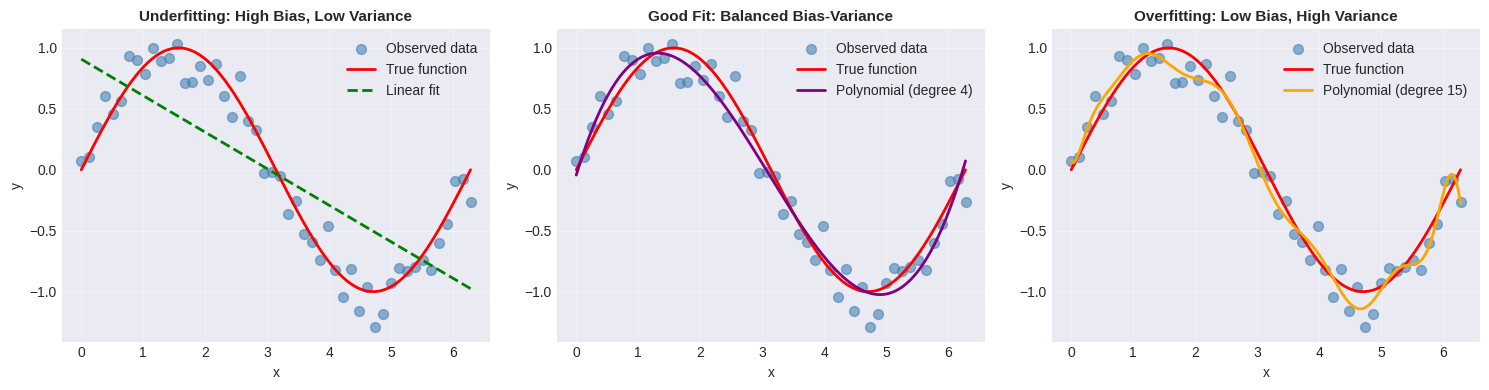

✓ Underfitting vs Overfitting visualization displayed!


In [2]:
# Generate synthetic data from y = sin(x) with noise
np.random.seed(42)
x = np.linspace(0, 2*np.pi, 50)
y_true = np.sin(x)
noise = np.random.normal(0, 0.15, size=x.shape)
y_observed = y_true + noise

x_fine = np.linspace(0, 2*np.pi, 300)
y_true_fine = np.sin(x_fine)

# Fit models of different complexity
p_linear = Polynomial.fit(x, y_observed, 1)
y_linear = p_linear(x_fine)

p_moderate = Polynomial.fit(x, y_observed, 4)
y_moderate = p_moderate(x_fine)

p_complex = Polynomial.fit(x, y_observed, 15)
y_complex = p_complex(x_fine)

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(x, y_observed, alpha=0.6, s=50, label='Observed data', color='steelblue')
axes[0].plot(x_fine, y_true_fine, 'r-', linewidth=2, label='True function')
axes[0].plot(x_fine, y_linear, 'g--', linewidth=2, label='Linear fit')
axes[0].set_title('Underfitting: High Bias, Low Variance', fontsize=11, fontweight='bold')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(x, y_observed, alpha=0.6, s=50, label='Observed data', color='steelblue')
axes[1].plot(x_fine, y_true_fine, 'r-', linewidth=2, label='True function')
axes[1].plot(x_fine, y_moderate, 'purple', linewidth=2, label='Polynomial (degree 4)')
axes[1].set_title('Good Fit: Balanced Bias-Variance', fontsize=11, fontweight='bold')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].scatter(x, y_observed, alpha=0.6, s=50, label='Observed data', color='steelblue')
axes[2].plot(x_fine, y_true_fine, 'r-', linewidth=2, label='True function')
axes[2].plot(x_fine, y_complex, 'orange', linewidth=2, label='Polynomial (degree 15)')
axes[2].set_title('Overfitting: Low Bias, High Variance', fontsize=11, fontweight='bold')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('✓ Underfitting vs Overfitting visualization displayed!')

In [3]:
# Quantify bias and variance across multiple datasets
np.random.seed(42)
n_datasets = 100
n_samples = 50

x_test = np.array([np.pi])
y_test_true = np.sin(x_test)[0]

predictions_linear = []
predictions_moderate = []
predictions_complex = []

for i in range(n_datasets):
    x = np.linspace(0, 2*np.pi, n_samples)
    y_true = np.sin(x)
    noise = np.random.normal(0, 0.15, size=x.shape)
    y_observed = y_true + noise
    
    p_linear = Polynomial.fit(x, y_observed, 1)
    p_moderate = Polynomial.fit(x, y_observed, 4)
    p_complex = Polynomial.fit(x, y_observed, 15)
    
    predictions_linear.append(p_linear(x_test)[0])
    predictions_moderate.append(p_moderate(x_test)[0])
    predictions_complex.append(p_complex(x_test)[0])

predictions_linear = np.array(predictions_linear)
predictions_moderate = np.array(predictions_moderate)
predictions_complex = np.array(predictions_complex)

# Calculate metrics
bias_linear = np.mean(predictions_linear) - y_test_true
bias_moderate = np.mean(predictions_moderate) - y_test_true
bias_complex = np.mean(predictions_complex) - y_test_true

var_linear = np.var(predictions_linear)
var_moderate = np.var(predictions_moderate)
var_complex = np.var(predictions_complex)

mse_linear = np.mean((predictions_linear - y_test_true)**2)
mse_moderate = np.mean((predictions_moderate - y_test_true)**2)
mse_complex = np.mean((predictions_complex - y_test_true)**2)

results_df = pd.DataFrame({
    'Model': ['Linear (Degree 1)', 'Moderate (Degree 4)', 'Complex (Degree 15)'],
    'Bias²': [bias_linear**2, bias_moderate**2, bias_complex**2],
    'Variance': [var_linear, var_moderate, var_complex],
    'MSE': [mse_linear, mse_moderate, mse_complex]
})

print('\n' + '='*70)
print('BIAS-VARIANCE DECOMPOSITION AT TEST POINT x = π')
print('='*70)
print(f'True value: y = sin(π) = {y_test_true:.4f}\n')
print(results_df.to_string(index=False))
print('\nNote: MSE = Bias² + Variance')
print('='*70)


BIAS-VARIANCE DECOMPOSITION AT TEST POINT x = π
True value: y = sin(π) = 0.0000

              Model        Bias²  Variance      MSE
  Linear (Degree 1) 7.060865e-07  0.000452 0.000452
Moderate (Degree 4) 5.601890e-06  0.001477 0.001482
Complex (Degree 15) 9.774289e-08  0.005422 0.005422

Note: MSE = Bias² + Variance


---
# Part 2: Regularization

## 2.1 The Problem and Solution

**Regularization** adds a penalty term to the loss function to prevent overfitting:

$$\min_\mathbf{w} \left[ (\mathbf{y} - \mathbf{X}^* \mathbf{w})^T(\mathbf{y} - \mathbf{X}^* \mathbf{w}) + \lambda \Omega(\mathbf{w}) \right]$$

where:
- First term: Training loss (MSE)
- $\lambda \Omega(\mathbf{w})$: Regularization penalty
- $\lambda$: Regularization rate (hyperparameter)

### How it works:
1. Choose a flexible model (high variance)
2. Add regularization penalty
3. Balance bias-variance tradeoff

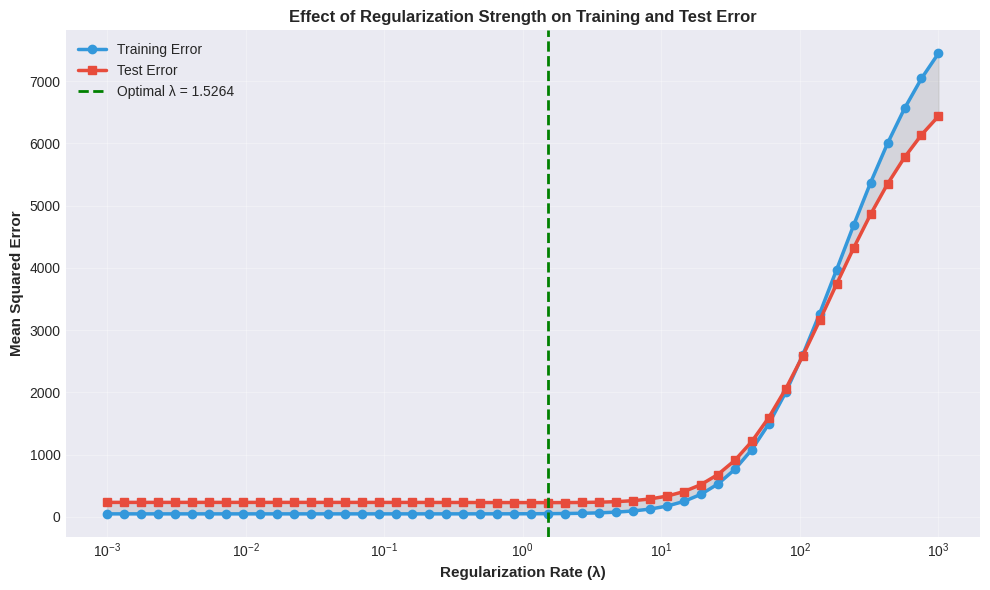

✓ Optimal regularization rate: λ = 1.526418
✓ Minimum test error: 229.2792


In [4]:
# Demonstrate regularization effect
np.random.seed(42)

X, y = make_regression(n_samples=100, n_features=20, n_informative=5, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lambdas = np.logspace(-3, 3, 50)
train_errors = []
test_errors = []

for lam in lambdas:
    ridge = Ridge(alpha=lam)
    ridge.fit(X_train_scaled, y_train)
    
    y_train_pred = ridge.predict(X_train_scaled)
    y_test_pred = ridge.predict(X_test_scaled)
    
    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(lambdas, train_errors, 'o-', linewidth=2.5, markersize=6, label='Training Error', color='#3498DB')
ax.semilogx(lambdas, test_errors, 's-', linewidth=2.5, markersize=6, label='Test Error', color='#E74C3C')
ax.fill_between(lambdas, train_errors, test_errors, alpha=0.2, color='gray')

optimal_idx = np.argmin(test_errors)
optimal_lambda = lambdas[optimal_idx]
ax.axvline(optimal_lambda, color='green', linestyle='--', linewidth=2, label=f'Optimal λ = {optimal_lambda:.4f}')

ax.set_xlabel('Regularization Rate (λ)', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Squared Error', fontsize=11, fontweight='bold')
ax.set_title('Effect of Regularization Strength on Training and Test Error', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'✓ Optimal regularization rate: λ = {optimal_lambda:.6f}')
print(f'✓ Minimum test error: {test_errors[optimal_idx]:.4f}')

---
# Part 3: Ridge Regression (L2 Regularization)

## 3.1 Ridge Regression Objective

Ridge regression adds an L2 penalty (squared magnitude of coefficients):

$$\min_\mathbf{w} \left[ (\mathbf{y} - \mathbf{X}^* \mathbf{w})^T(\mathbf{y} - \mathbf{X}^* \mathbf{w}) + \lambda ||\mathbf{w}||_2^2 \right]$$

### Closed-Form Solution
$$\mathbf{w}_{\text{ridge}} = (\mathbf{X}^T\mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^T\mathbf{y}$$

### Key Properties
- Shrinks all coefficients smoothly
- Larger coefficients shrunk more
- No coefficients exactly zero
- Handles multicollinearity well

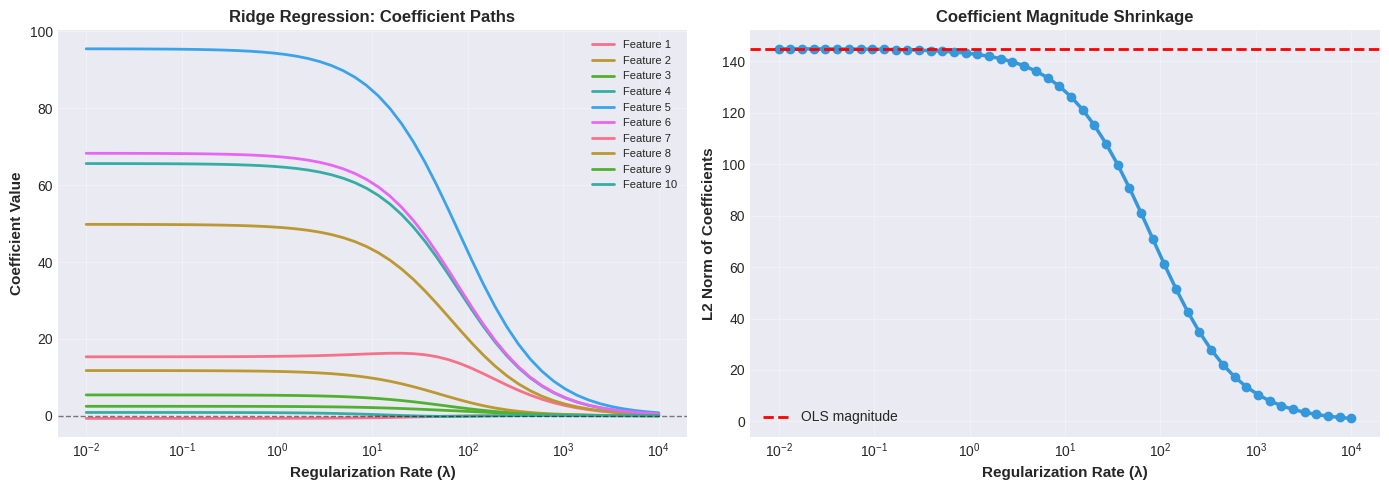

✓ Ridge regression coefficient analysis completed!


In [5]:
# Ridge Regression: Coefficient Shrinkage
np.random.seed(42)

X, y = make_regression(n_samples=100, n_features=10, n_informative=8, noise=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lambdas = np.logspace(-2, 4, 50)
coefficients = []

ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
ols_coef = ols.coef_.copy()

for lam in lambdas:
    ridge = Ridge(alpha=lam)
    ridge.fit(X_train_scaled, y_train)
    coefficients.append(ridge.coef_)

coefficients = np.array(coefficients)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(X_train_scaled.shape[1]):
    axes[0].semilogx(lambdas, coefficients[:, i], linewidth=2, label=f'Feature {i+1}')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Regularization Rate (λ)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Coefficient Value', fontsize=11, fontweight='bold')
axes[0].set_title('Ridge Regression: Coefficient Paths', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8, loc='best')
axes[0].grid(True, alpha=0.3)

coef_magnitude = np.linalg.norm(coefficients, axis=1)
axes[1].semilogx(lambdas, coef_magnitude, 'o-', linewidth=2.5, markersize=6, color='#3498DB')
axes[1].axhline(y=np.linalg.norm(ols_coef), color='red', linestyle='--', linewidth=2, label='OLS magnitude')
axes[1].set_xlabel('Regularization Rate (λ)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('L2 Norm of Coefficients', fontsize=11, fontweight='bold')
axes[1].set_title('Coefficient Magnitude Shrinkage', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('✓ Ridge regression coefficient analysis completed!')

---
# Part 4: Lasso Regression (L1 Regularization)

## 4.1 Lasso Regression Objective

**LASSO** (Least Absolute Shrinkage and Selection Operator) uses an L1 penalty:

$$\min_\mathbf{w} \left[ (\mathbf{y} - \mathbf{X}^* \mathbf{w})^T(\mathbf{y} - \mathbf{X}^* \mathbf{w}) + \lambda ||\mathbf{w}||_1 \right]$$

### Key Properties
- Can drive coefficients exactly to zero
- Performs automatic feature selection
- Produces sparse models
- No closed-form solution (uses coordinate descent)

### Why Sparse Solutions?
The L1 constraint region (diamond) has sharp corners at the axes. When error contours touch the constraint, they often touch at a corner where one or more coefficients are exactly zero.

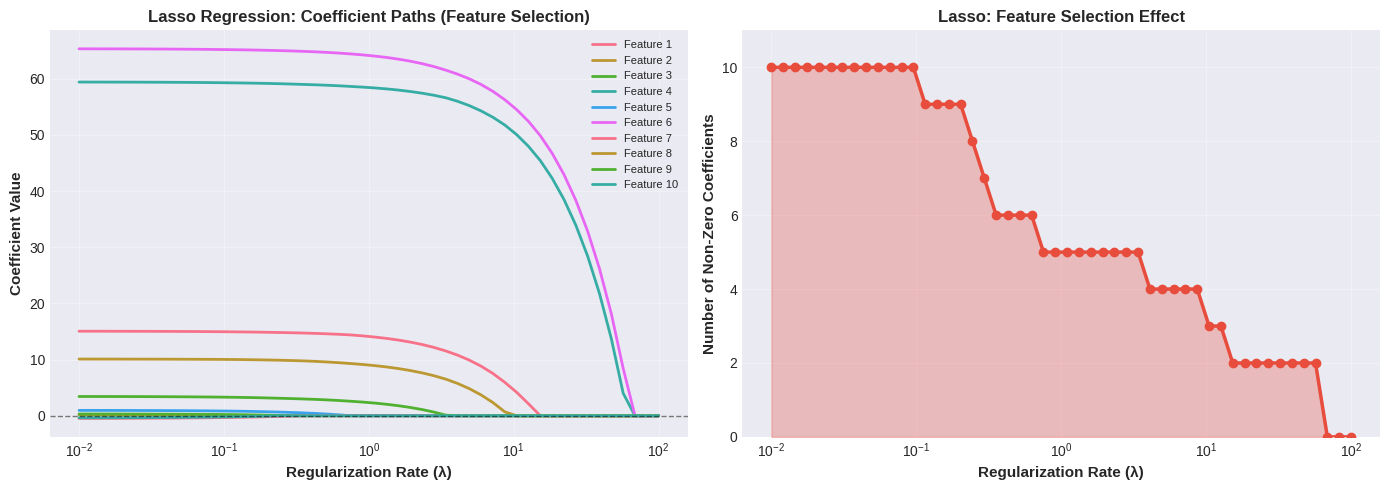

✓ Lasso regression coefficient analysis completed!


In [6]:
# Lasso Regression: Coefficient Shrinkage and Feature Selection
np.random.seed(42)

X, y = make_regression(n_samples=100, n_features=10, n_informative=5, noise=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lambdas = np.logspace(-2, 2, 50)
lasso_coefficients = []
n_nonzero = []

for lam in lambdas:
    lasso = Lasso(alpha=lam, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_coefficients.append(lasso.coef_)
    n_nonzero.append(np.sum(lasso.coef_ != 0))

lasso_coefficients = np.array(lasso_coefficients)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(X_train_scaled.shape[1]):
    axes[0].semilogx(lambdas, lasso_coefficients[:, i], linewidth=2, label=f'Feature {i+1}')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('Regularization Rate (λ)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Coefficient Value', fontsize=11, fontweight='bold')
axes[0].set_title('Lasso Regression: Coefficient Paths (Feature Selection)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8, loc='best')
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(lambdas, n_nonzero, 'o-', linewidth=2.5, markersize=6, color='#E74C3C')
axes[1].fill_between(lambdas, 0, n_nonzero, alpha=0.3, color='#E74C3C')
axes[1].set_xlabel('Regularization Rate (λ)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Non-Zero Coefficients', fontsize=11, fontweight='bold')
axes[1].set_title('Lasso: Feature Selection Effect', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, X_train_scaled.shape[1] + 1])

plt.tight_layout()
plt.show()

print('✓ Lasso regression coefficient analysis completed!')

---
# Part 5: Ridge vs Lasso Comparison

## 5.1 Key Differences

| Aspect | Ridge (L2) | Lasso (L1) |
|--------|-----------|----------|
| **Penalty** | $\lambda ||\mathbf{w}||_2^2$ | $\lambda ||\mathbf{w}||_1$ |
| **Shrinkage** | Smooth, proportional | Uniform |
| **Coefficients to zero** | Rarely | Can be exactly zero |
| **Feature selection** | No | Yes |
| **Sparse solutions** | Dense | Sparse |
| **Solution** | Closed-form | Coordinate descent |

## 5.2 When to Use

**Ridge:** All features potentially relevant, multicollinearity present

**Lasso:** Many features irrelevant, need feature selection, sparse model desired

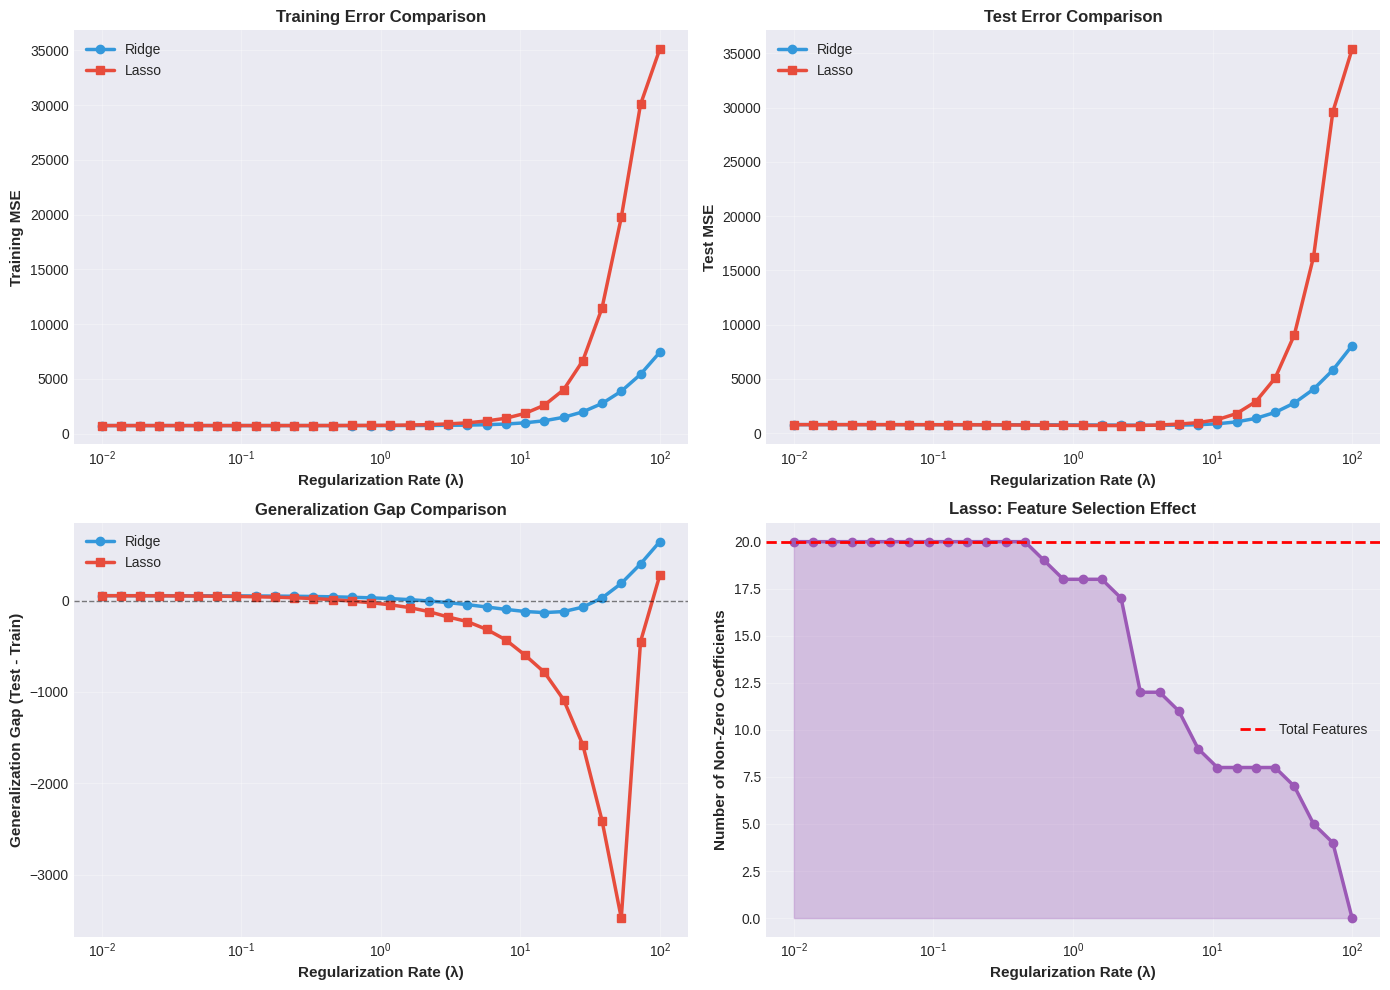

✓ Ridge vs Lasso comparison completed!


In [7]:
# Direct comparison of Ridge and Lasso
np.random.seed(42)

X, y = make_regression(n_samples=150, n_features=20, n_informative=10, noise=30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lambdas = np.logspace(-2, 2, 30)
ridge_train_errors = []
ridge_test_errors = []
lasso_train_errors = []
lasso_test_errors = []
lasso_nonzero = []

for lam in lambdas:
    ridge = Ridge(alpha=lam)
    ridge.fit(X_train_scaled, y_train)
    ridge_train_errors.append(mean_squared_error(y_train, ridge.predict(X_train_scaled)))
    ridge_test_errors.append(mean_squared_error(y_test, ridge.predict(X_test_scaled)))
    
    lasso = Lasso(alpha=lam, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_train_errors.append(mean_squared_error(y_train, lasso.predict(X_train_scaled)))
    lasso_test_errors.append(mean_squared_error(y_test, lasso.predict(X_test_scaled)))
    lasso_nonzero.append(np.sum(lasso.coef_ != 0))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].semilogx(lambdas, ridge_train_errors, 'o-', linewidth=2.5, markersize=6, label='Ridge', color='#3498DB')
axes[0, 0].semilogx(lambdas, lasso_train_errors, 's-', linewidth=2.5, markersize=6, label='Lasso', color='#E74C3C')
axes[0, 0].set_xlabel('Regularization Rate (λ)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Training MSE', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Training Error Comparison', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].semilogx(lambdas, ridge_test_errors, 'o-', linewidth=2.5, markersize=6, label='Ridge', color='#3498DB')
axes[0, 1].semilogx(lambdas, lasso_test_errors, 's-', linewidth=2.5, markersize=6, label='Lasso', color='#E74C3C')
axes[0, 1].set_xlabel('Regularization Rate (λ)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Test MSE', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Test Error Comparison', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

ridge_gap = np.array(ridge_test_errors) - np.array(ridge_train_errors)
lasso_gap = np.array(lasso_test_errors) - np.array(lasso_train_errors)
axes[1, 0].semilogx(lambdas, ridge_gap, 'o-', linewidth=2.5, markersize=6, label='Ridge', color='#3498DB')
axes[1, 0].semilogx(lambdas, lasso_gap, 's-', linewidth=2.5, markersize=6, label='Lasso', color='#E74C3C')
axes[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 0].set_xlabel('Regularization Rate (λ)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Generalization Gap (Test - Train)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Generalization Gap Comparison', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].semilogx(lambdas, lasso_nonzero, 'o-', linewidth=2.5, markersize=6, color='#9B59B6')
axes[1, 1].fill_between(lambdas, 0, lasso_nonzero, alpha=0.3, color='#9B59B6')
axes[1, 1].axhline(y=X_train_scaled.shape[1], color='red', linestyle='--', linewidth=2, label='Total Features')
axes[1, 1].set_xlabel('Regularization Rate (λ)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Number of Non-Zero Coefficients', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Lasso: Feature Selection Effect', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('✓ Ridge vs Lasso comparison completed!')

---
# Summary and Key Takeaways

## Key Concepts

### 1. Bias-Variance Tradeoff
- **Bias:** Systematic error from model simplicity (underfitting)
- **Variance:** Error from model sensitivity to training data (overfitting)
- **Fundamental truth:** Total error = Bias² + Variance + Irreducible Error
- **Tradeoff:** As model complexity increases, bias decreases but variance increases

### 2. Regularization
- **Purpose:** Control model complexity to prevent overfitting
- **Mechanism:** Add penalty term to loss function
- **Effect:** Shrink coefficients, reduce variance at cost of small bias increase
- **Hyperparameter:** Regularization rate λ controls strength

### 3. Ridge Regression (L2)
- **Penalty:** Sum of squared coefficients
- **Solution:** Closed-form available
- **Shrinkage:** Smooth, all coefficients remain non-zero
- **Use case:** When all features are potentially